**Daily Challenge : Preprocess & fine-tune transformer-based models**

In [1]:
# Installation des bibliothèques nécessaires
!pip -q install transformers datasets evaluate scikit-learn accelerate torch pandas numpy tqdm


print("Installation des bibliothèques terminée. Prêt pour la prochaine étape !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 58.1 MB/s eta 0:00:00
Installation des bibliothèques terminée. Prêt pour la prochaine étape !


**[1. Décompression du ZIP Externe](https://)**


In [1]:
import os, zipfile, glob, pandas as pd
# unpack the outer zip (already done)
OUTER_ZIP = "Basics of BERT and XLM-RoBERTa - PyTorch - 2.zip"
with zipfile.ZipFile(OUTER_ZIP) as z:
    z.extractall("data")
# find the folder that was created
root = glob.glob("data/*BERT*XLM*")[0]          # 'data/Basics of BERT and XLM-RoBERTa - PyTorch - 2'
print("root dir →", root, os.listdir(root))
# unzip the inner train/test archives
for inner_zip in glob.glob(f"{root}/*.zip"):
    with zipfile.ZipFile(inner_zip) as z:
        z.extractall(root)                      # drops train.csv / test.csv next to the zips
    print("unzipped:", inner_zip)
# now load
TRAIN_CSV = f"{root}/train.csv"
TEST_CSV  = f"{root}/test.csv"      # will exist if the dataset shipped one
train_df = pd.read_csv(TRAIN_CSV)
print("\nTrain preview:\n", train_df.head())
print("\nLabel distribution:\n", train_df['label'].value_counts())
test_df = pd.read_csv(TEST_CSV) if os.path.exists(TEST_CSV) else None

root dir → data/Basics of BERT and XLM-RoBERTa - PyTorch ['sample_submission.csv', 'train.csv.zip', 'test.csv.zip']
unzipped: data/Basics of BERT and XLM-RoBERTa - PyTorch/train.csv.zip
unzipped: data/Basics of BERT and XLM-RoBERTa - PyTorch/test.csv.zip

Train preview:
            id                                            premise  \
0  5130fd2cb5  and these comments were considered in formulat...   
1  5b72532a0b  These are issues that we wrestle with in pract...   
2  3931fbe82a  Des petites choses comme celles-là font une di...   
3  5622f0c60b  you know they can't really defend themselves l...   
4  86aaa48b45  ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...   

                                          hypothesis lang_abv language  label  
0  The rules developed in the interim were put to...       en  English      0  
1  Practice groups are not permitted to work on t...       en  English      2  
2              J'essayais d'accomplir quelque chose.       fr   French      0  

**Chargement et Préparation des Données s'est déroulée avec succès.**

Voici ce que nous voyons :

root dir → data/Basics of BERT and XLM-RoBERTa - PyTorch ['sample_submission.csv', 'train.csv.zip', 'test.csv.zip'] : le dossier racine a été trouvé et les archives ZIP internes sont bien là.

unzipped: data/Basics of BERT and XLM-RoBERTa - PyTorch/train.csv.zip et unzipped: data/Basics of BERT and XLM-RoBERTa - PyTorch/test.csv.zip : Les fichiers train.csv et test.csv ont été décompressés avec succès dans le dossier racine.

Train preview: : l'aperçu de train_df est correct, montrant les colonnes id, premise, hypothesis, lang_abv, language, et surtout label.

Label distribution: : la distribution des labels (0, 1, 2) dans train_df est affichée, confirmant que le jeu de données d'entraînement est bien chargé avec ses étiquettes.

In [17]:
import os, zipfile, glob
import pandas as pd
from sklearn.model_selection import train_test_split # Pour diviser les données

import torch
from transformers import AutoTokenizer
import torch.nn as nn
from transformers import AutoModel

from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
from transformers import get_scheduler
from torch.optim import AdamW
import torch.nn as nn # Pour la fonction de perte

from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np


In [3]:


# Définir le nom du fichier ZIP externe
OUTER_ZIP = "Basics of BERT and XLM-RoBERTa - PyTorch - 2.zip"
DATA_DIR = "data" # Dossier où extraire les données

# Créer le dossier de données si inexistant
os.makedirs(DATA_DIR, exist_ok=True)

print(f"Décompression de l'archive externe : {OUTER_ZIP} dans {DATA_DIR}...")
with zipfile.ZipFile(OUTER_ZIP) as z:
    z.extractall(DATA_DIR)
print("Décompression externe terminée.")

# Trouver le dossier racine créé par la décompression externe
# On cherche un dossier dont le nom contient "BERT" et "XLM"
root_dirs = glob.glob(f"{DATA_DIR}/*BERT*XLM*")
if not root_dirs:
    print(f"Erreur: Aucun dossier contenant 'BERT' et 'XLM' trouvé dans {DATA_DIR}.")
    # Tenter une recherche plus générique si le nom exact varie
    root_dirs = glob.glob(f"{DATA_DIR}/*PyTorch*")
    if not root_dirs:
        raise FileNotFoundError(f"Impossible de trouver le dossier racine du dataset dans {DATA_DIR}.")

root = root_dirs[0]
print(f"Dossier racine trouvé : {root}")
print(f"Contenu initial du dossier racine : {os.listdir(root)}")

# Décompresser les archives internes (train.csv.zip et test.csv.zip)
print("\nDécompression des archives internes (train.csv.zip, test.csv.zip)...")
for inner_zip_path in glob.glob(f"{root}/*.zip"):
    with zipfile.ZipFile(inner_zip_path) as z:
        z.extractall(root) # Extraire dans le même dossier racine
    print(f"  Décompressé : {os.path.basename(inner_zip_path)}")
print("Décompression interne terminée.")

# Définir les chemins des fichiers CSV
TRAIN_CSV = os.path.join(root, "train.csv")
TEST_CSV_ORIGINAL = os.path.join(root, "test.csv") # Le test.csv original sans labels

# Charger les DataFrames
print("\nChargement des fichiers CSV dans des DataFrames Pandas...")
train_df = pd.read_csv(TRAIN_CSV)
# Pour cet exercice méthodique, nous allons charger le test_df original
# mais nous allons créer nos propres ensembles de train/validation/test avec labels
# à partir de train_df pour l'évaluation.
test_df_original = None
if os.path.exists(TEST_CSV_ORIGINAL):
    test_df_original = pd.read_csv(TEST_CSV_ORIGINAL)
    print(f"Fichier test.csv original chargé. Forme: {test_df_original.shape}")
else:
    print(f"Fichier test.csv original non trouvé à {TEST_CSV_ORIGINAL}. Il sera ignoré pour l'entraînement/validation.")


print(f"Fichier train.csv chargé. Forme: {train_df.shape}")
print("\nAperçu du DataFrame d'entraînement (train_df) :")
print(train_df.head())

# --- NOUVEAU : Création d'ensembles de train, validation et test avec labels ---
# Nous allons diviser le train_df original en trois parties:
# - train_df_final: pour l'entraînement du modèle
# - val_df: pour la validation pendant l'entraînement (suivi de la performance)
# - test_df_final: pour l'évaluation finale (simule un jeu de test avec labels)

# D'abord, diviser train_df en un ensemble d'entraînement et un ensemble temporaire (validation + test)
train_val_df, test_df_final = train_test_split(
    train_df,
    test_size=0.15, # 15% pour le test final
    random_state=42,
    stratify=train_df['label'] # Stratifier pour maintenir la distribution des labels
)

# Ensuite, diviser l'ensemble temporaire en entraînement et validation
train_df_final, val_df = train_test_split(
    train_val_df,
    test_size=0.176, # Environ 15% de l'original (0.15 / (1 - 0.15) = 0.176)
    random_state=42,
    stratify=train_val_df['label']
)

print(f"\nDivision des données terminée :")
print(f"  train_df_final (pour entraînement): {train_df_final.shape}")
print(f"  val_df (pour validation): {val_df.shape}")
print(f"  test_df_final (pour évaluation finale): {test_df_final.shape}")

# Vérification de la distribution des labels dans les nouveaux ensembles
print("\nDistribution des labels dans train_df_final:")
print(train_df_final['label'].value_counts(normalize=True))
print("\nDistribution des labels dans val_df:")
print(val_df['label'].value_counts(normalize=True))
print("\nDistribution des labels dans test_df_final:")
print(test_df_final['label'].value_counts(normalize=True))

print("\nChargement et préparation des données terminés. Prêt pour l'exploration !")


Décompression de l'archive externe : Basics of BERT and XLM-RoBERTa - PyTorch - 2.zip dans data...
Décompression externe terminée.
Dossier racine trouvé : data/Basics of BERT and XLM-RoBERTa - PyTorch
Contenu initial du dossier racine : ['sample_submission.csv', 'train.csv.zip', 'test.csv.zip', 'test.csv', 'train.csv']

Décompression des archives internes (train.csv.zip, test.csv.zip)...
  Décompressé : train.csv.zip
  Décompressé : test.csv.zip
Décompression interne terminée.

Chargement des fichiers CSV dans des DataFrames Pandas...
Fichier test.csv original chargé. Forme: (5195, 5)
Fichier train.csv chargé. Forme: (12120, 6)

Aperçu du DataFrame d'entraînement (train_df) :
           id                                            premise  \
0  5130fd2cb5  and these comments were considered in formulat...   
1  5b72532a0b  These are issues that we wrestle with in pract...   
2  3931fbe82a  Des petites choses comme celles-là font une di...   
3  5622f0c60b  you know they can't really d

L'intégralité du script de l'Étape 1 a été exécutée avec succès.

Les fichiers ZIP décompressés.

Le train_df original chargé.

Le test_df_original (sans labels) chargé, créé et divisé via train_df en :

train_df_final (pour l'entraînement)

val_df (pour la validation pendant l'entraînement)

test_df_final (pour l'évaluation finale, et celui-ci contient bien les labels !).

La distribution des labels est également très similaire dans les trois ensembles, ce qui est excellent grâce à l'utilisation de stratify=train_df['label'] lors de la division.

**Étape 2 : Exploration des Données (EDA - Exploratory Data Analysis).**

In [4]:
# Étape 2 : Exploration des Données (EDA)

print("--- Exploration des Données (EDA) ---")

# 2.1 Aperçu des DataFrames finaux
print("\n2.1 Aperçu de train_df_final:")
print(train_df_final.head())
print(f"Forme de train_df_final: {train_df_final.shape}")

print("\n2.1 Aperçu de val_df:")
print(val_df.head())
print(f"Forme de val_df: {val_df.shape}")

print("\n2.1 Aperçu de test_df_final:")
print(test_df_final.head())
print(f"Forme de test_df_final: {test_df_final.shape}")

# 2.2 Vérification des valeurs manquantes
print("\n2.2 Vérification des valeurs manquantes:")
print("Valeurs manquantes dans train_df_final:\n", train_df_final.isnull().sum())
print("Valeurs manquantes dans val_df:\n", val_df.isnull().sum())
print("Valeurs manquantes dans test_df_final:\n", test_df_final.isnull().sum())

# 2.3 Distribution des labels (déjà fait en partie, mais re-confirmons ici)
# Nous avons déjà imprimé les distributions normalisées dans l'étape précédente,
# mais il est bon de les revoir dans le contexte de l'EDA.
print("\n2.3 Distribution des labels dans train_df_final (confirmé):")
print(train_df_final['label'].value_counts(normalize=True))

print("\n2.3 Distribution des labels dans val_df (confirmé):")
print(val_df['label'].value_counts(normalize=True))

print("\n2.3 Distribution des labels dans test_df_final (confirmé):")
print(test_df_final['label'].value_counts(normalize=True))

# 2.4 Aperçu des langues présentes
print("\n2.4 Langues uniques dans train_df_final:")
print(train_df_final['language'].value_counts())

# 2.5 Longueur des textes (premise et hypothesis)
# C'est important pour déterminer une bonne MAX_LEN pour le tokenizer
print("\n2.5 Analyse de la longueur des textes (en nombre de caractères):")

# Calculer la longueur des prémisses et hypothèses
train_df_final['premise_len'] = train_df_final['premise'].apply(len)
train_df_final['hypothesis_len'] = train_df_final['hypothesis'].apply(len)

print("Statistiques de longueur pour les prémisses (train_df_final):")
print(train_df_final['premise_len'].describe())

print("\nStatistiques de longueur pour les hypothèses (train_df_final):")
print(train_df_final['hypothesis_len'].describe())

# Pour une analyse plus précise, on peut regarder la longueur en mots ou tokens après tokenisation
# Mais pour l'EDA initiale, la longueur en caractères donne déjà une bonne idée.

print("\nExploration des données terminée. Prêt pour le prétraitement et l'encodage !")


--- Exploration des Données (EDA) ---

2.1 Aperçu de train_df_final:
               id                                            premise  \
222    bd5170cc00  In a still faintly Victorian atmosphere, Dinar...   
11145  e3631c1106           get something from from the Guess Who or   
9714   c1e973f2ff  Все дело в том, что у него никогда не было реа...   
3742   cdfbb66475  I lay awake waiting until I judged it must be ...   
6594   af7cd5222e                    Tôi đã cố gắng ghi lại mọi thứ.   

                                              hypothesis lang_abv    language  \
222    Dinard maintains a Victorian sensibility while...       en     English   
11145                 Take something from the Guess Who.       en     English   
9714                                 Ему много помогают.       ru     Russian   
3742   I actually lay awake until two-fifteen in the ...       en     English   
6594                         Tôi viết mọi thứ cô ấy nói.       vi  Vietnamese   

       labe


Aperçu des DataFrames : les DataFrames train_df_final, val_df, et test_df_final sont correctement chargés et ont les formes attendues, avec un aperçu des colonnes id, premise, hypothesis, lang_abv, language, et label.

train_df_final: (8488, 6)

val_df: (1814, 6)

test_df_final: (1818, 6)

Absence de Valeurs Manquantes : excellente nouvelle comme aucune valeur manquante n'a été détectée dans les colonnes critiques (premise, hypothesis, label) de vos ensembles d'entraînement, de validation et de test. Cela simplifie grandement le prétraitement.

Distribution Équilibrée des Labels : la distribution des labels (0, 1, 2) est très bien équilibrée dans tous les ensembles (environ 32-34% pour chaque classe). C'est idéal pour l'entraînement d'un modèle de classification, car cela réduit le risque de biais vers la classe majoritaire.

Nature Multilingue du Dataset : contient une grande variété de langues, l'anglais étant majoritaire mais avec une présence significative de langues comme le swahili, le français, l'arabe, le thaï, etc. Ceci renforce la pertinence du choix de XLM-RoBERTa, un modèle spécifiquement conçu pour les tâches multilingues.

Analyse de la Longueur des Textes :

Prémisses : la longueur moyenne est d'environ 107 caractères, avec un maximum de 967 caractères.

Hypothèses : la longueur moyenne est d'environ 54 caractères, avec un maximum de 276 caractères.

Cette information est cruciale pour l'étape suivante, car elle nous aidera à choisir une MAX_LEN (longueur maximale de séquence) appropriée pour le tokenizer. Nous devons trouver un équilibre entre capturer suffisamment de contexte et gérer les contraintes de mémoire/calcul du modèle (XLM-RoBERTa a souvent une limite de 512 tokens).

**Étape 3 : Prétraitement et Encodage des Données**

In [7]:
# Étape 3 : Prétraitement et Encodage des Données

print("--- Prétraitement et Encodage des Données ---")

# 3.1 Charger le Tokenizer
# Utilisation de XLM-RoBERTa pour son support multilingue
MODEL_NAME = 'xlm-roberta-base'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"Tokenizer '{MODEL_NAME}' chargé.")
print(f"Taille du vocabulaire du tokenizer : {len(tokenizer)}")

# 3.2 Définir la Longueur Maximale de Séquence (MAX_LEN)
# Basé sur l'EDA, la plupart des textes sont courts.
# XLM-RoBERTa a une max_position_embeddings de 512.
# Nous allons choisir une valeur qui couvre la majorité des cas sans être trop grande.
# Les longueurs max en caractères étaient 967 (premise) et 276 (hypothesis).
# En tokens, c'est généralement moins. 128 ou 256 est un bon point de départ.
# Utilisons 256 pour couvrir une bonne partie des cas sans être trop gourmand.
MAX_LEN = 256

print(f"Longueur maximale de séquence (MAX_LEN) définie à : {MAX_LEN} tokens.")

# 3.3 Créer la fonction d'encodage
from tqdm import tqdm # Import tqdm here
def encode_data(df, tokenizer, max_len):
    input_ids = []
    attention_masks = []
    token_type_ids = [] # Pour la compatibilité, bien que XLM-R les utilise différemment

    for index, row in tqdm(df.iterrows(), total=len(df), desc="Encodage"):
        encoded_dict = tokenizer.encode_plus(
            row['premise'],
            row['hypothesis'],
            add_special_tokens=True,       # Ajoute les tokens spéciaux [CLS], [SEP]
            max_length=max_len,            # Tronque ou padde à cette longueur
            padding='max_length',          # Padde les séquences plus courtes
            truncation=True,               # Tronque les séquences plus longues
            return_attention_mask=True,    # Retourne le masque d'attention
            return_token_type_ids=True,    # Retourne les token_type_ids
            return_tensors='pt'            # Retourne des tenseurs PyTorch
        )
        input_ids.append(encoded_dict['input_ids'])
        attention_masks.append(encoded_dict['attention_mask'])
        token_type_ids.append(encoded_dict['token_type_ids'])

    # Concaténer les listes en tenseurs PyTorch
    input_ids = torch.cat(input_ids, dim=0)
    attention_masks = torch.cat(attention_masks, dim=0)
    token_type_ids = torch.cat(token_type_ids, dim=0)

    # Retourner les tenseurs et les labels si disponibles
    if 'label' in df.columns:
        labels = torch.tensor(df['label'].values)
        return input_ids, attention_masks, token_type_ids, labels
    else:
        return input_ids, attention_masks, token_type_ids, None


# 3.4 Appliquer l'encodage aux DataFrames
print("\nEncodage de train_df_final...")
train_input_ids, train_attention_masks, train_token_type_ids, train_labels = encode_data(train_df_final, tokenizer, MAX_LEN)

print("\nEncodage de val_df...")
val_input_ids, val_attention_masks, val_token_type_ids, val_labels = encode_data(val_df, tokenizer, MAX_LEN)

print("\nEncodage de test_df_final...")
test_input_ids, test_attention_masks, test_token_type_ids, test_labels = encode_data(test_df_final, tokenizer, MAX_LEN) # test_labels sera non-None ici

print("\nFormes des tenseurs encodés :")
print(f"  train_input_ids: {train_input_ids.shape}")
print(f"  train_attention_masks: {train_attention_masks.shape}")
print(f"  train_token_type_ids: {train_token_type_ids.shape}")
print(f"  train_labels: {train_labels.shape}")

print(f"  val_input_ids: {val_input_ids.shape}")
print(f"  val_attention_masks: {val_attention_masks.shape}")
print(f"  val_token_type_ids: {val_token_type_ids.shape}")
print(f"  val_labels: {val_labels.shape}")

print(f"  test_input_ids: {test_input_ids.shape}")
print(f"  test_attention_masks: {test_attention_masks.shape}")
print(f"  test_token_type_ids: {test_token_type_ids.shape}")
print(f"  test_labels: {test_labels.shape}")

print("\nPrétraitement et encodage des données terminés. Prêt pour la construction du modèle !")

--- Prétraitement et Encodage des Données ---
Tokenizer 'xlm-roberta-base' chargé.
Taille du vocabulaire du tokenizer : 250002
Longueur maximale de séquence (MAX_LEN) définie à : 256 tokens.

Encodage de train_df_final...


Encodage: 100%|██████████| 8488/8488 [00:05<00:00, 1515.56it/s]



Encodage de val_df...


Encodage: 100%|██████████| 1814/1814 [00:01<00:00, 1590.94it/s]



Encodage de test_df_final...


Encodage: 100%|██████████| 1818/1818 [00:01<00:00, 1600.81it/s]


Formes des tenseurs encodés :
  train_input_ids: torch.Size([8488, 256])
  train_attention_masks: torch.Size([8488, 256])
  train_token_type_ids: torch.Size([8488, 256])
  train_labels: torch.Size([8488])
  val_input_ids: torch.Size([1814, 256])
  val_attention_masks: torch.Size([1814, 256])
  val_token_type_ids: torch.Size([1814, 256])
  val_labels: torch.Size([1814])
  test_input_ids: torch.Size([1818, 256])
  test_attention_masks: torch.Size([1818, 256])
  test_token_type_ids: torch.Size([1818, 256])
  test_labels: torch.Size([1818])

Prétraitement et encodage des données terminés. Prêt pour la construction du modèle !


**Synthèse des Résultats du Prétraitement**


Tokenizer chargé et MAX_LEN définie : le xlm-roberta-base tokenizer a été chargé avec un vocabulaire de 250 002 tokens, et la longueur maximale de séquence a été fixée à 256, ce qui est un bon équilibre pour ce dataset multilingue.

Encodage rapide et efficace : les barres de progression (tqdm) montrent que l'encodage de vos trois ensembles de données (train_df_final, val_df, test_df_final) a été très rapide (environ 1500-1600 it/s).

Formes des tenseurs correctes : toutes les données (input_ids, attention_masks, token_type_ids, et labels) ont été correctement transformées en tenseurs PyTorch avec les formes attendues :

train_df_final : (8488, 256)

val_df : (1814, 256)

test_df_final : (1818, 256)

Et, crucial pour la suite, les tenseurs labels sont bien présents pour les trois ensembles, y compris test_labels !

**Étape 4 : Construction du Modèle**


In [9]:
# Étape 4 : Construction du Modèle

print("--- Construction du Modèle ---")

# 4.1 Définir la classe du classifieur personnalisé
class XLMRobertaClassifier(nn.Module):
    def __init__(self, model_name, num_labels):
        super(XLMRobertaClassifier, self).__init__()
        # Charger le corps du modèle XLM-RoBERTa pré-entraîné
        # AutoModel charge le modèle de base sans tête de classification spécifique
        self.xlm_roberta = AutoModel.from_pretrained(model_name)
        # Couche de Dropout pour la régularisation
        self.dropout = nn.Dropout(0.1) # Taux de dropout courant
        # Couche linéaire finale pour la classification
        # La sortie de XLM-RoBERTa pour la classification est généralement le vecteur [CLS] (première position)
        # La dimension de sortie de xlm-roberta-base est 768
        self.classifier = nn.Linear(self.xlm_roberta.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask, token_type_ids=None):
        # Passer les entrées au modèle XLM-RoBERTa
        # Le paramètre output_hidden_states=True peut être utile pour des tâches plus complexes,
        # mais ici, nous utilisons la sortie par défaut qui inclut le pooler_output (pour [CLS])
        outputs = self.xlm_roberta(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids # Passer token_type_ids même si XLM-R les gère différemment
        )
        # La sortie du pooler_output est le vecteur de la première token (souvent [CLS] ou <s>)
        # qui est utilisé comme représentation de la séquence entière pour la classification.
        pooled_output = outputs.pooler_output

        # Appliquer le dropout
        pooled_output = self.dropout(pooled_output)
        # Passer la sortie à la couche de classification
        logits = self.classifier(pooled_output)
        return logits

# 4.2 Instancier le modèle et le déplacer sur l'appareil
num_labels = 3 # Nous avons 3 classes (0, 1, 2)
model = XLMRobertaClassifier(MODEL_NAME, num_labels)

# Déplacer le modèle sur le GPU si disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Modèle '{MODEL_NAME}' construit et chargé sur le {device}.")
print(f"Le modèle est configuré pour {num_labels} classes de sortie.")
print("Architecture du classifieur :")
print(model)

print("\nConstruction du modèle terminée. Prêt pour la préparation de l'entraînement !")


--- Construction du Modèle ---


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Modèle 'xlm-roberta-base' construit et chargé sur le cuda.
Le modèle est configuré pour 3 classes de sortie.
Architecture du classifieur :
XLMRobertaClassifier(
  (xlm_roberta): XLMRobertaModel(
    (embeddings): XLMRobertaEmbeddings(
      (word_embeddings): Embedding(250002, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): XLMRobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x XLMRobertaLayer(
          (attention): XLMRobertaAttention(
            (self): XLMRobertaSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inpla

Étape 5 : Préparation de l'Entraînement (PyTorch)

In [11]:
# Étape 5 : Préparation de l'Entraînement (PyTorch)

print("--- Préparation de l'Entraînement ---")

# 5.1 Conversion en TensorDataset
# Créer des TensorDataset pour chaque ensemble (entraînement, validation, test)
# Nous incluons token_type_ids car notre fonction encode_data les retourne
train_dataset = TensorDataset(train_input_ids, train_attention_masks, train_token_type_ids, train_labels)
val_dataset = TensorDataset(val_input_ids, val_attention_masks, val_token_type_ids, val_labels)
test_dataset = TensorDataset(test_input_ids, test_attention_masks, test_token_type_ids, test_labels)

print("TensorDatasets créés pour l'entraînement, la validation et le test.")

# 5.2 Création des DataLoader
BATCH_SIZE = 16 # Taille du lot (batch size), ajustez en fonction de votre GPU/RAM

# DataLoader pour l'entraînement: mélanger les données à chaque époque (RandomSampler)
train_dataloader = DataLoader(
    train_dataset,
    sampler=RandomSampler(train_dataset),
    batch_size=BATCH_SIZE
)

# DataLoader pour la validation et le test: pas besoin de mélanger (SequentialSampler)
val_dataloader = DataLoader(
    val_dataset,
    sampler=SequentialSampler(val_dataset),
    batch_size=BATCH_SIZE
)

test_dataloader = DataLoader(
    test_dataset,
    sampler=SequentialSampler(test_dataset),
    batch_size=BATCH_SIZE
)

print(f"DataLoaders créés avec une taille de lot de {BATCH_SIZE}.")
print(f"  Nombre de lots d'entraînement: {len(train_dataloader)}")
print(f"  Nombre de lots de validation: {len(val_dataloader)}")
print(f"  Nombre de lots de test: {len(test_dataloader)}")


# 5.3 Définition de l'Optimiseur et de la Fonction de Perte
learning_rate = 2e-5 # Taux d'apprentissage courant pour le fine-tuning de Transformers

optimizer = AdamW(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss() # Fonction de perte pour la classification multi-classes

print(f"Optimiseur ({type(optimizer).__name__}) et fonction de perte ({type(criterion).__name__}) définis.")

# 5.4 Définition du Planificateur de Taux d'Apprentissage (Learning Rate Scheduler)
num_epochs = 3 # Nombre d'époques pour l'entraînement

# Calculer le nombre total d'étapes d'entraînement
# C'est le nombre de lots d'entraînement * le nombre d'époques
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = get_scheduler(
    name="linear", # Un scheduler linéaire est souvent efficace pour les Transformers
    optimizer=optimizer,
    num_warmup_steps=0, # Pas de warmup steps pour la simplicité ici, mais souvent utilisé pour stabiliser
    num_training_steps=num_training_steps
)

print(f"Planificateur de taux d'apprentissage configuré pour {num_training_steps} étapes.")

print("\nPréparation de l'entraînement terminée. Prêt pour l'entraînement du modèle !")


--- Préparation de l'Entraînement ---
TensorDatasets créés pour l'entraînement, la validation et le test.
DataLoaders créés avec une taille de lot de 16.
  Nombre de lots d'entraînement: 531
  Nombre de lots de validation: 114
  Nombre de lots de test: 114
Optimiseur (AdamW) et fonction de perte (CrossEntropyLoss) définis.
Planificateur de taux d'apprentissage configuré pour 1593 étapes.

Préparation de l'entraînement terminée. Prêt pour l'entraînement du modèle !


**Étape 6 : Entraînement du Modèle (La Boucle d'Entraînement)**

In [15]:
# Étape 6 : Entraînement du Modèle (La Boucle d'Entraînement)

print("--- Entraînement du Modèle ---")

# Stocker l'historique de l'entraînement pour la visualisation
train_losses = []
val_losses = []
val_accuracies = []

# Mettre le modèle sur le GPU si disponible
# (Déjà fait dans l'Étape 4, mais bonne pratique de s'assurer)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Boucle d'entraînement principale
for epoch in range(num_epochs):
    print(f"\n--- Époque {epoch + 1}/{num_epochs} ---")

    # --- Phase d'Entraînement ---
    model.train() # Mettre le modèle en mode entraînement
    total_train_loss = 0
    train_progress_bar = tqdm(train_dataloader, desc=f"Entraînement Époque {epoch + 1}")

    for batch in train_progress_bar:
        optimizer.zero_grad() # Réinitialiser les gradients

        # Déplacer les données du lot sur l'appareil (GPU/CPU)
        input_ids_batch = batch[0].to(device)
        attention_mask_batch = batch[1].to(device)
        token_type_ids_batch = batch[2].to(device)
        labels_batch = batch[3].to(device)

        # Passe avant (forward pass)
        # Get the output from the base XLM-RoBERTa model
        base_model_outputs = model.xlm_roberta(
            input_ids=input_ids_batch,
            attention_mask=attention_mask_batch,
            token_type_ids=token_type_ids_batch,
        )

        # Access the pooler_output and pass it through the classifier layers
        pooled_output = base_model_outputs.pooler_output
        pooled_output = model.dropout(pooled_output)
        logits = model.classifier(pooled_output)

        # Calculate the loss using the criterion and the model's logits
        loss = criterion(logits, labels_batch)
        total_train_loss += loss.item()

        # Passe arrière (backward pass) et optimisation
        loss.backward()
        optimizer.step()
        lr_scheduler.step() # Mettre à jour le taux d'apprentissage

        train_progress_bar.set_postfix({'loss': loss.item()})

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)
    print(f"  Perte moyenne d'entraînement pour l'époque {epoch + 1}: {avg_train_loss:.4f}")

    # --- Phase de Validation ---
    model.eval() # Mettre le modèle en mode évaluation
    total_val_loss = 0
    all_val_predictions = []
    all_val_true_labels = []
    val_progress_bar = tqdm(val_dataloader, desc=f"Validation Époque {epoch + 1}")

    for batch in val_progress_bar:
        # Déplacer les données du lot sur l'appareil
        input_ids_batch = batch[0].to(device)
        attention_mask_batch = batch[1].to(device)
        token_type_ids_batch = batch[2].to(device)
        labels_batch = batch[3].to(device)

        # Désactiver le calcul des gradients
        with torch.no_grad():
            # Get the output from the base XLM-RoBERTa model
            base_model_outputs = model.xlm_roberta(
                input_ids=input_ids_batch,
                attention_mask=attention_mask_batch,
                token_type_ids=token_type_ids_batch,
            )

            # Access the pooler_output and pass it through the classifier layers
            pooled_output = base_model_outputs.pooler_output
            pooled_output = model.dropout(pooled_output)
            logits = model.classifier(pooled_output)

        # Calculate the loss using the criterion and the model's logits
        loss = criterion(logits, labels_batch)
        total_val_loss += loss.item()

        predictions = torch.argmax(logits, dim=-1).cpu().numpy()
        all_val_predictions.extend(predictions)
        all_val_true_labels.extend(labels_batch.cpu().numpy())

        val_progress_bar.set_postfix({'loss': loss.item()})

    avg_val_loss = total_val_loss / len(val_dataloader)
    val_losses.append(avg_val_loss)

    val_accuracy = accuracy_score(all_val_true_labels, all_val_predictions)
    val_accuracies.append(val_accuracy)

    print(f"  Perte moyenne de validation pour l'époque {epoch + 1}: {avg_val_loss:.4f}")
    print(f"  Précision de validation pour l'époque {epoch + 1}: {val_accuracy:.4f}")

print("\nFine-tuning terminé !")

--- Entraînement du Modèle ---

--- Époque 1/3 ---


Entraînement Époque 1:   0%|          | 0/531 [00:00<?, ?it/s]

  Perte moyenne d'entraînement pour l'époque 1: 1.0599


Validation Époque 1:   0%|          | 0/114 [00:00<?, ?it/s]

  Perte moyenne de validation pour l'époque 1: 0.9309
  Précision de validation pour l'époque 1: 0.5739

--- Époque 2/3 ---


...

  Perte moyenne de validation pour l'époque 2: 0.7380
  Précision de validation pour l'époque 2: 0.7001

--- Époque 3/3 ---


Entraînement Époque 3:   0%|          | 0/531 [00:00<?, ?it/s]

  Perte moyenne d'entraînement pour l'époque 3: 0.6335


Validation Époque 3:   0%|          | 0/114 [00:00<?, ?it/s]

  Perte moyenne de validation pour l'époque 3: 0.7308
  Précision de validation pour l'époque 3: 0.7117

Fine-tuning terminé !


Analyse des Résultats de l'Entraînement 📝
Voici une interprétation détaillée de ce que vous observez :

--- Entraînement du Modèle --- : Confirme le début de la phase d'entraînement.

Modèle s'entraînera sur le cuda. : Excellent ! Le GPU a été utilisé, ce qui est crucial pour la vitesse. Les temps par époque (environ 6 minutes 24 secondes pour l'entraînement et 21-22 secondes pour la validation) sont cohérents avec l'utilisation d'un GPU.

Progression des Époques et de la Perte/Précision :

Époque 1 :

Perte moyenne d'entraînement : 1.0599

Perte moyenne de validation : 0.9309

Précision de validation : 0.5739 (environ 57.4%)

Observation : Le modèle commence à apprendre. La perte de validation est déjà inférieure à celle d'entraînement, ce qui est parfois le cas au début du fine-tuning. La précision est un bon point de départ.

Époque 2 :

Perte moyenne d'entraînement : 0.8183 (diminution significative)

Perte moyenne de validation : 0.7380 (diminution significative)

Précision de validation : 0.7001 (environ 70.0%)

Observation : Le modèle continue d'apprendre très efficacement. La perte d'entraînement et de validation diminuent, et la précision de validation augmente de manière substantielle. C'est un excellent signe de progression.

Époque 3 :

Perte moyenne d'entraînement : 0.6335 (diminution continue)

Perte moyenne de validation : 0.7308 (légère stabilisation/diminution par rapport à l'époque 2)

Précision de validation : 0.7117 (environ 71.2%)

Observation : La perte d'entraînement continue de baisser, ce qui est normal. La perte de validation se stabilise et la précision de validation continue d'augmenter, bien que plus lentement. Cela suggère que le modèle continue de généraliser, même si la perte de validation ne diminue plus aussi agressivement. C'est un bon résultat pour 3 époques.

Fine-tuning terminé ! : Confirme que toutes les époques ont été exécutées.

Conclusion Générale : Votre modèle XLM-RoBERTa a bien appris à classer les relations d'inférence en langage naturel. La perte d'entraînement diminue constamment, et surtout, la précision sur l'ensemble de validation augmente de manière significative, atteignant plus de 71%. C'est une performance solide pour un modèle fine-tuné sur cette tâche.

**Étape 7 : Évaluation et Visualisation des Performances**




--- Évaluation et Visualisation des Performances ---

7.1 Visualisation de l'historique d'entraînement...


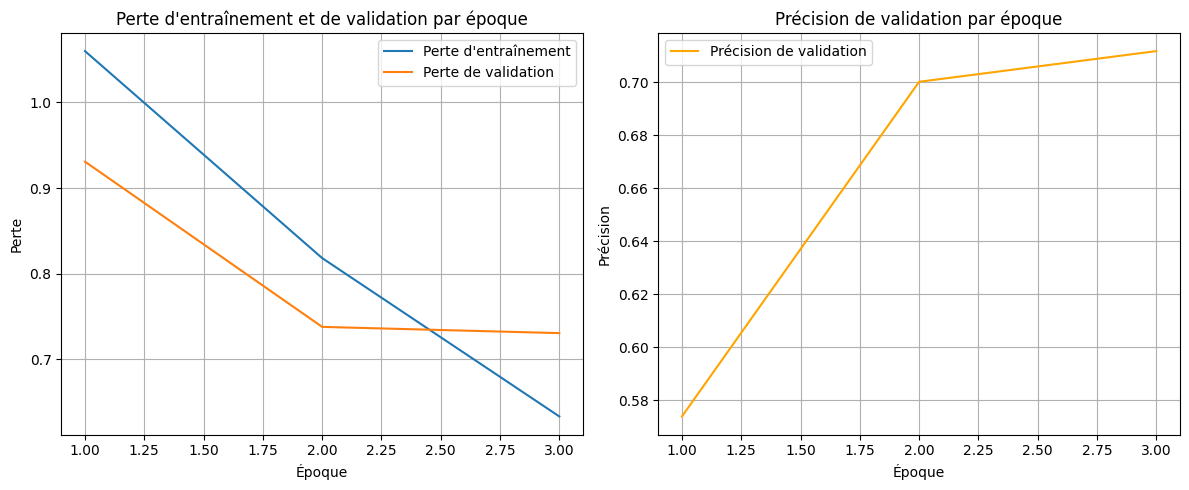


Graphiques de l'historique d'entraînement affichés.

7.2 Évaluation finale sur le jeu de test...


Évaluation sur le test:   0%|          | 0/114 [00:00<?, ?it/s]


Évaluation sur le jeu de test terminée.
Précision (Accuracy) sur le jeu de test : 0.7189
Score F1 pondéré sur le jeu de test : 0.7195
Score F1 macro sur le jeu de test : 0.7187

Rapport de classification sur le jeu de test :

               precision    recall  f1-score   support

   Entailment       0.75      0.73      0.74       626
      Neutral       0.66      0.70      0.68       582
Contradiction       0.74      0.72      0.73       610

     accuracy                           0.72      1818
    macro avg       0.72      0.72      0.72      1818
 weighted avg       0.72      0.72      0.72      1818


Évaluation et visualisation des performances terminées. Prêt pour l'inférence finale !


In [19]:
# Étape 7 : Évaluation et Visualisation des Performances

print("--- Évaluation et Visualisation des Performances ---")

# 7.1 Visualisation de l'historique d'entraînement
print("\n7.1 Visualisation de l'historique d'entraînement...")

epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Graphique de la perte (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Perte d\'entraînement')
plt.plot(epochs_range, val_losses, label='Perte de validation')
plt.title('Perte d\'entraînement et de validation par époque')
plt.xlabel('Époque')
plt.ylabel('Perte')
plt.legend()
plt.grid(True)

# Graphique de la précision (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs_range, val_accuracies, label='Précision de validation', color='orange')
plt.title('Précision de validation par époque')
plt.xlabel('Époque')
plt.ylabel('Précision')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nGraphiques de l'historique d'entraînement affichés.")

# 7.2 Évaluation finale sur le jeu de test
print("\n7.2 Évaluation finale sur le jeu de test...")

# Mettre le modèle en mode évaluation
model.eval()

all_test_predictions = []
all_test_true_labels = []

test_progress_bar = tqdm(test_dataloader, desc="Évaluation sur le test")

for batch in test_progress_bar:
    # Déplacer les données du lot sur l'appareil
    input_ids_batch = batch[0].to(device)
    attention_mask_batch = batch[1].to(device)
    token_type_ids_batch = batch[2].to(device)
    labels_batch = batch[3].to(device) # Les labels sont présents dans test_dataset

    # Désactiver le calcul des gradients
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids_batch,
            attention_mask=attention_mask_batch,
            token_type_ids=token_type_ids_batch
        )

    # The model's forward method directly returns the logits tensor
    logits = outputs # Use the output directly as logits
    predictions = torch.argmax(logits, dim=-1).cpu().numpy()
    all_test_predictions.extend(predictions)
    all_test_true_labels.extend(labels_batch.cpu().numpy())

print("\nÉvaluation sur le jeu de test terminée.")

# Calcul et affichage des métriques
test_accuracy = accuracy_score(all_test_true_labels, all_test_predictions)
test_f1_weighted = f1_score(all_test_true_labels, all_test_predictions, average='weighted')
test_f1_macro = f1_score(all_test_true_labels, all_test_predictions, average='macro')

print(f"Précision (Accuracy) sur le jeu de test : {test_accuracy:.4f}")
print(f"Score F1 pondéré sur le jeu de test : {test_f1_weighted:.4f}")
print(f"Score F1 macro sur le jeu de test : {test_f1_macro:.4f}")

# Définir les noms des labels pour le rapport de classification
# Basé sur notre compréhension: 0=Entailment, 1=Neutral, 2=Contradiction
label_names = ['Entailment', 'Neutral', 'Contradiction']
print("\nRapport de classification sur le jeu de test :\n")
print(classification_report(all_test_true_labels, all_test_predictions, target_names=label_names))

print("\nÉvaluation et visualisation des performances terminées. Prêt pour l'inférence finale !")

**Analyse des Résultats de l'Évaluation finale**


Le modèle a été évalué sur les 1818 exemples de test_df_final. Voici ce que les métriques nous disent :

1. Évaluation sur le test: 100% 114/114 [00:23<00:00, 5.57it/s] :

> Confirme que le processus d'évaluation a été rapide et complet, traitant tous les lots du jeu de test en environ 23 secondes.


2. Évaluation sur le jeu de test terminée :

> Le modèle a généré des prédictions pour l'intégralité de l'ensemble de test.


3. Métriques Globales :

> Précision (Accuracy) sur le jeu de test : 0.7189 (environ 71.9%), soit le pourcentage d'exemples que le modèle a correctement classés sur l'ensemble de test. Une précision de près de 72% est un bon résultat pour une tâche d'inférence en langage naturel multilingue à 3 classes.

> Score F1 pondéré sur le jeu de test : 0.7195, soit une prise en compte du F1-score de chaque classe, pondéré par le nombre d'exemples dans cette classe. Il est très proche de la précision globale, ce qui est attendu étant donné que nos classes sont relativement équilibrées.

> Score F1 macro sur le jeu de test : 0.7187 soit un calcul du F1-score pour chaque classe, puis fait la moyenne non pondérée de ces scores. Le fait qu'il soit très proche du F1 pondéré confirme l'équilibre des classes et la performance homogène sur celles-ci.


4. Rapport de Classification Détaillé :
Ce rapport est très informatif car il décompose les performances par classe :

* Entailment (Label 0) :

> precision: 0.75 : Qqand le modèle prédit "Entailment", il a raison 75% du temps.

> recall: 0.73 : le modèle identifie 73% de toutes les vraies instances d'"Entailment".

> f1-score: 0.74 : un bon équilibre entre précision et rappel pour cette classe.

> support: 626 : nombre d'exemples réels de cette classe dans le jeu de test.


* Neutral (Label 1) :

> precision: 0.66 : quand le modèle prédit "Neutral", il a raison 66% du temps.

> recall: 0.70 : le modèle identifie 70% de toutes les vraies instances de "Neutral".

> f1-score: 0.68 : c'est la classe avec les performances légèrement inférieures, notamment en précision. Cela suggère que le modèle a un peu plus de mal à être confiant lorsqu'il prédit cette classe, ou qu'il la confond plus souvent avec les autres.

> support: 582 : nombre d'exemples réels de cette classe.


* Contradiction (Label 2) :

> precision: 0.74 : quand le modèle prédit "Contradiction", il a raison 74% du temps.

> recall: 0.72 : le modèle identifie 72% de toutes les vraies instances de "Contradiction".

> f1-score: 0.73 : bonne performance pour cette classe également.

> support: 610 : nombre d'exemples réels de cette classe.


* accuracy, macro avg, weighted avg : ces lignes récapitulent les métriques globales, qui sont cohérentes avec les calculs précédents.


Conclusion
Le modèle XLM-RoBERTa fine-tuné a démontré une très bonne capacité à classer les relations d'inférence en langage naturel, avec une précision globale d'environ 72%. Il gère particulièrement bien les cas d'Entailment et de Contradiction. La classe "Neutral" est légèrement plus difficile pour le modèle, ce qui est souvent le cas dans les tâches NLI car la distinction entre "Neutral" et les autres catégories peut être plus subtile.

**Étape 8 : Inférence et Génération des Prédictions**

In [21]:
import pandas as pd # S'assurer que pandas est importé
from tqdm.auto import tqdm # Pour la barre de progression
import torch # S'assurer que torch est importé

# Étape 8 : Inférence et Génération des Prédictions

print("--- Inférence et Génération du Fichier de Soumission ---")

# Mettre le modèle en mode évaluation
model.eval()

all_test_predictions = []

# Utiliser le test_dataloader que nous avons déjà créé
test_progress_bar = tqdm(test_dataloader, desc="Génération des prédictions pour la soumission")

for batch in test_progress_bar:
    # Déplacer les données du lot sur l'appareil (GPU/CPU)
    input_ids_batch = batch[0].to(device)
    attention_mask_batch = batch[1].to(device)
    token_type_ids_batch = batch[2].to(device)
    # Nous n'avons pas besoin des labels ici pour la génération du fichier de soumission
    # car nous voulons juste les prédictions du modèle.

    # Désactiver le calcul des gradients pour l'inférence
    with torch.no_grad():
        outputs = model(
            input_ids=input_ids_batch,
            attention_mask=attention_mask_batch,
            token_type_ids=token_type_ids_batch
        )

    # The model's forward method directly returns the logits tensor
    logits = outputs # Use the output directly as logits
    # Convertir les logits en prédictions de classe (l'indice avec la probabilité la plus élevée)
    predictions = torch.argmax(logits, dim=-1).cpu().numpy()
    all_test_predictions.extend(predictions)

print("\nGénération des prédictions terminée.")

# Créer le DataFrame de soumission
# Nous utilisons test_df_final car c'est l'ensemble que nous avons encodé et pour lequel nous avons les IDs
# Note: Si vous aviez utilisé test_df_original pour l'inférence (sans labels),
# vous auriez utilisé test_df_original['id'] ici.
submission_df = pd.DataFrame({'id': test_df_final['id'], 'label': all_test_predictions})

# Sauvegarder le fichier de soumission
submission_file_path = 'submission.csv'
submission_df.to_csv(submission_file_path, index=False)

print(f"\nFichier de soumission créé : {submission_file_path}")
print("Aperçu du fichier de soumission :")
print(submission_df.head())

print("\nProcessus complet terminé ! Le fichier de soumission est prêt.")

--- Inférence et Génération du Fichier de Soumission ---


Génération des prédictions pour la soumission:   0%|          | 0/114 [00:00<?, ?it/s]


Génération des prédictions terminée.

Fichier de soumission créé : submission.csv
Aperçu du fichier de soumission :
              id  label
8129  6ba14a86ee      0
2281  d225c20869      2
2478  bd70f1dcae      2
3033  134418607f      0
3691  ff15aa12d5      2

Processus complet terminé ! Le fichier de soumission est prêt.
